#  과제 문제

## 1. 과제 목표
- PJM_Load_hourly 데이터 분석 리포트 작성
- 수업시간에 배운 데이터 분석 기법 활용  

---

## 2. 제출 내용

### 1) 데이터 처리
- 제공된 시간별(Hourly) 데이터를 이용하여 , 일별(Daily) 및 월별(Monthly) 데이터로 변환한 뒤 각 단위별로 예측 성능 비교 분석할 것

### 2) ARIMA 모델 기반 예측
- ACF, PACF 그래프를 활용하여 ARIMA의 p, d, q 파라미터 찾기
- 시점별 영향력 평가하고 예측 결과를 시각화하여 분석

### 3) 3. Facebook Prophet 모델 기반 예측
 - 동일 데이터셋에 Prophet 모델을 적용하여 ARIMA와의 성능 및 추세 비교 수행(시각화 포함)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# (한글 폰트 설정 - 선택)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 파일 읽기 및 컬럼 분리
df = pd.read_csv('./data/PJM_Load_hourly.txt', header=0)
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y-%m-%d %H:%M')
df.set_index('Datetime', inplace=True)
df['PJM_Load_MW'] = pd.to_numeric(df['PJM_Load_MW'], errors='coerce')

# PJM_Load_hourly 데이터 읽고 변환 분석

# 1-1. 데이터 일별, 월별 변환

In [3]:
# 일별 평균 데이터 변환
df_daily = df.resample('D').mean()
print(df_daily.head())

             PJM_Load_MW
Datetime                
1998-04-01  27813.739130
1998-04-02  26605.791667
1998-04-03  25672.333333
1998-04-04  24487.083333
1998-04-05  23487.565217


In [4]:
# 월별 평균 데이터 변환
df_monthly = df.resample('M').mean()
print(df_monthly.head())

             PJM_Load_MW
Datetime                
1998-04-30  25429.250696
1998-05-31  26766.952957
1998-06-30  29741.420833
1998-07-31  32862.901882
1998-08-31  33179.141129


C:\Users\a6742\AppData\Local\Temp\ipykernel_19912\2863623690.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M').mean()


# 1-2. 변환 데이터의 정상성 확인

In [5]:
# 각 분할한 데이터의 정상성 확인
result_daily = adfuller(df_daily['PJM_Load_MW'])
result_monthly = adfuller(df_monthly['PJM_Load_MW'])

print("일별 데이터 p-value: ", result_daily[1])
print("월별 데이터 p-value: ", result_monthly[1])


일별 데이터 p-value:  0.005054018216633149
월별 데이터 p-value:  1.0337083259314223e-11


In [6]:
# p-value가 모두 0.05 이하로 정상성 가짐
d = 0
y_diff_daily = df_daily['PJM_Load_MW']
y_diff_monthly = df_monthly['PJM_Load_MW']

for i in range(d):
    y_diff_daily = y_diff_daily.diff().dropna()
    y_diff_monthly = y_diff_monthly.diff().dropna()

result_diff_daily = adfuller(y_diff_daily)
result_diff_monthly = adfuller(y_diff_monthly)
print("차분 후 일별 데이터 p-value: ", result_diff_daily[1])
print("차분 후 월별 데이터 p-value: ", result_diff_monthly[1])

차분 후 일별 데이터 p-value:  0.005054018216633149
차분 후 월별 데이터 p-value:  1.0337083259314223e-11


# ARIMA 모델 기반 예측

# 2-1. 일별 ACF, PACF 그래프

<Figure size 640x480 with 0 Axes>

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


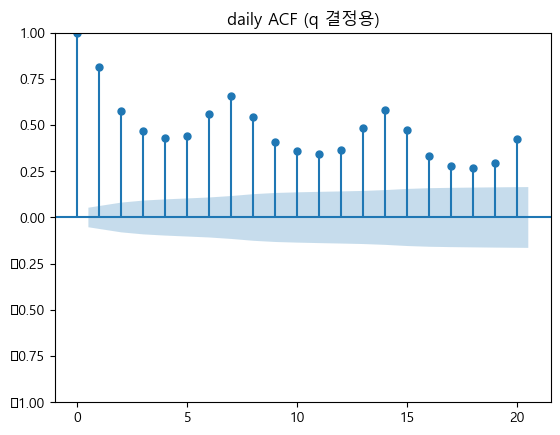

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


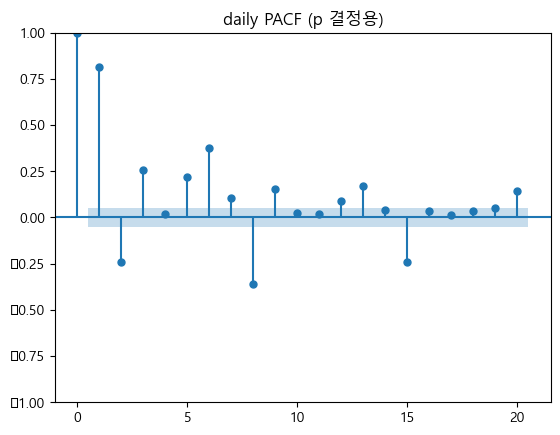

In [7]:
# daily p, q 값 결정

plt.figure()
plot_acf(y_diff_daily, lags=20)
plt.title("daily ACF (q 결정용)")
plt.show()
plot_pacf(y_diff_daily, lags=20)
plt.title("daily PACF (p 결정용)")
plt.show()


# 2-2. 월별 ACF, PACF 그래프

<Figure size 640x480 with 0 Axes>

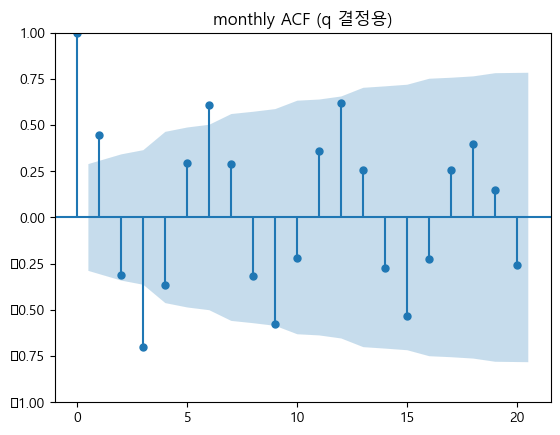

<Figure size 640x480 with 0 Axes>

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


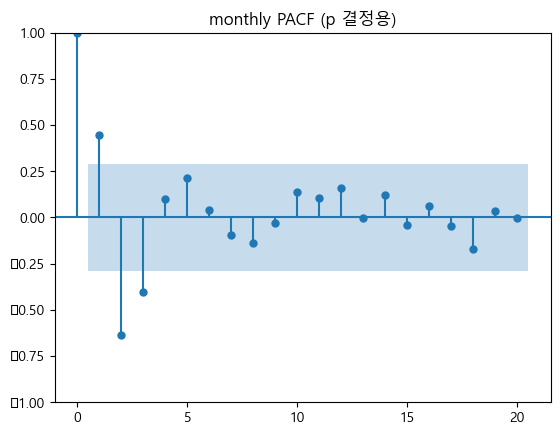

In [8]:
# Monthly p, q 값 결정

plt.figure()
plot_acf(y_diff_monthly, lags=20)
plt.title("monthly ACF (q 결정용)")
plt.show()

plt.figure()
plot_pacf(y_diff_monthly, lags=20)
plt.title("monthly PACF (p 결정용)")
plt.show()

# 2-3. 모델 학습 데이터 분류

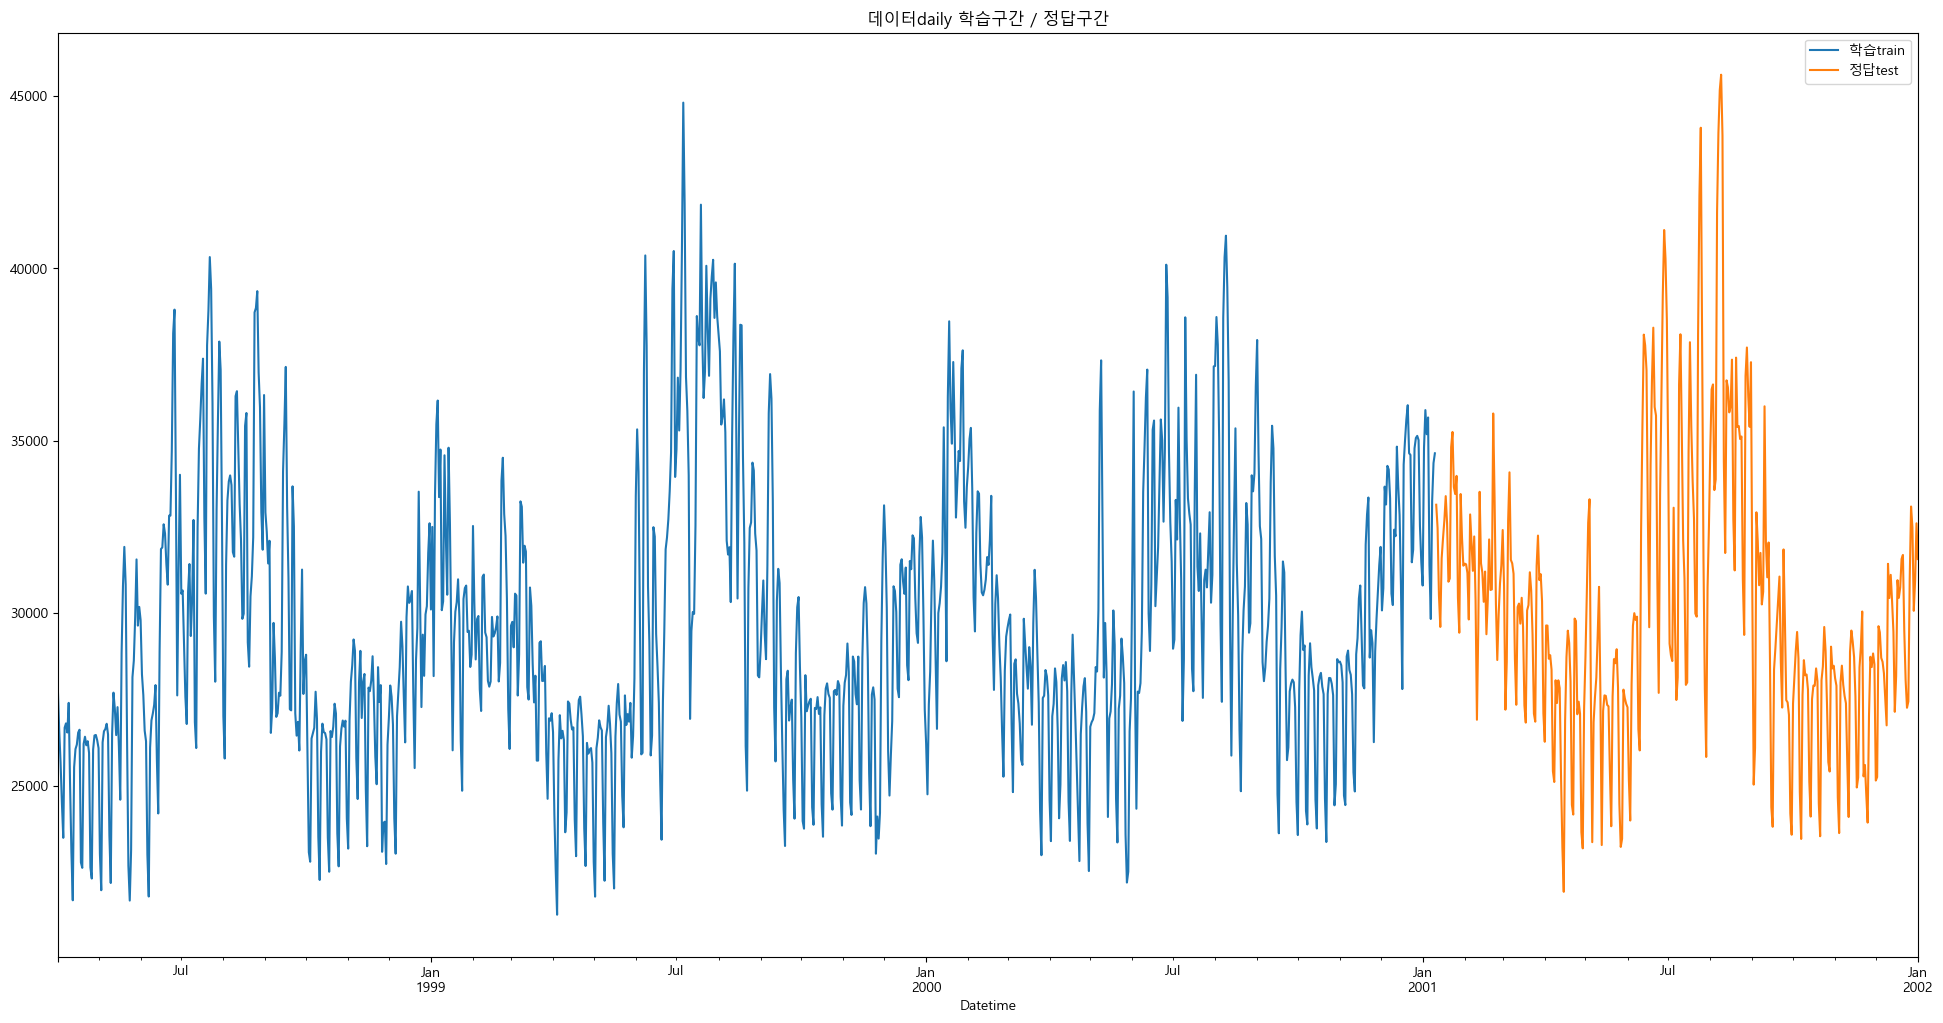

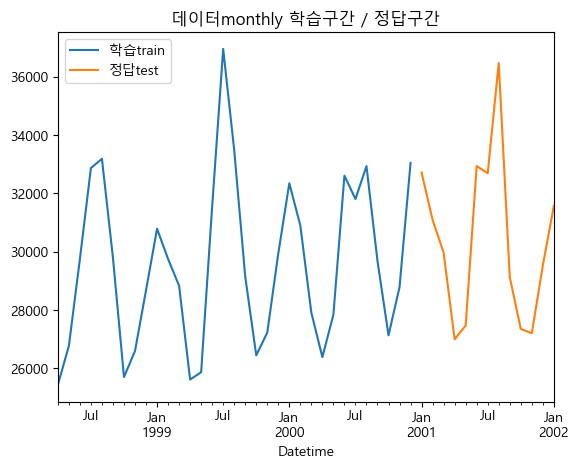

In [9]:
# 데이터 분리
h1 = 356            # 일별 예측 356일
h2 = 13             # 월별 예측 13개월

y_daily = df_daily['PJM_Load_MW']
y_monthly = df_monthly['PJM_Load_MW']

y_daily_train = y_daily.iloc[:-h1]
y_daily_test = y_daily.iloc[-h1:]

y_monthly_train = y_monthly.iloc[:-h2]
y_monthly_test = y_monthly.iloc[-h2:]   

plt.figure(figsize=(24, 12))
plt.title("데이터daily 학습구간 / 정답구간")
y_daily_train.plot(label='학습train')
y_daily_test.plot(label='정답test')
plt.legend()
plt.show()

plt.figure()
plt.title("데이터monthly 학습구간 / 정답구간")
y_monthly_train.plot(label='학습train')
y_monthly_test.plot(label='정답test')
plt.legend()
plt.show()


# 2-4. 일별 데이터 P, Q 파라미터 

In [10]:
# 일별 P, Q 값
P_list = [1, 2, 3, 5, 6, 7, 8, 9]
Q_list = [1, 2, 3, 4, 6, 7, 8, 13, 14]
d_daily = 0

results = []

for p in P_list:
    for q in Q_list:
        try:
            model_daily = ARIMA(y_daily_train, order=(p, d_daily, q))
            fit_daily = model_daily.fit()
            fc_daily = fit_daily.get_forecast(steps=h1)
            pred_daily = fc_daily.predicted_mean
            pred_daily.index = y_daily_test.index
            
            # 성능 평가
            rmse_daily = float(np.sqrt(np.mean((y_daily_test.values - pred_daily.values)**2)))
            mape_daily = float(np.mean(np.abs((y_daily_test.values - pred_daily.values) / y_daily_test.values))) * 100
            
            # 결과 저장
            results.append({
                'p': p,
                'q': q,
                'RMSE': rmse_daily,
                'MAPE': mape_daily
            })
        except Exception as e:
            results.append({
                'p': p,
                'q': q,
                'RMSE': np.nan,
                'MAPE': np.nan,
                'error': str(e)
            })


results_df = pd.DataFrame(results)
print(results_df.sort_values('MAPE').reset_index(drop=True))

# 가장 MAPE가 낮은 조합 확인
best_row = results_df.loc[results_df['MAPE'].idxmin()]
print(f"최적 조합: p={best_row['p']}, q={best_row['q']}, RMSE={best_row['RMSE']:.2f}, MAPE={best_row['MAPE']:.2f}%")


c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive param

    p   q         RMSE       MAPE
0   9  14  3677.686089   8.668989
1   9  13  3796.897700   8.865496
2   8  13  3741.076706   8.939349
3   8   7  3851.374475   8.948875
4   9   7  3791.480766   8.956282
.. ..  ..          ...        ...
67  5   8  4864.426032  14.829800
68  1  14  4962.883703  14.914453
69  3  13  5018.689745  15.154291
70  3  14  5127.988063  15.560169
71  3   6  5267.041218  16.132299

[72 rows x 4 columns]
최적 조합: p=9.0, q=14.0, RMSE=3677.69, MAPE=8.67%


# # 2-5. 월별 데이터 P, Q 파라미터 

In [11]:
P_list = [1, 2, 3, 4, 5]
Q_list = [1, 2, 3, 4, 6, 7]
d_monthly = 0

results_monthly = []

for p in P_list:
    for q in Q_list:
        try:
            model_monthly = ARIMA(y_monthly_train, order=(p, d_monthly, q))
            fit_monthly = model_monthly.fit()
            fc_monthly = fit_monthly.get_forecast(steps=h2)
            pred_monthly = fc_monthly.predicted_mean
            pred_monthly.index = y_monthly_test.index

            # 성능 평가
            rmse_monthly = float(np.sqrt(np.mean((y_monthly_test.values - pred_monthly.values)**2)))
            mape_monthly = float(np.mean(np.abs((y_monthly_test.values - pred_monthly.values) / y_monthly_test.values))) * 100

            # 결과 저장
            results_monthly.append({
                'p': p,
                'q': q,
                'RMSE': rmse_monthly,
                'MAPE': mape_monthly
            })
        except Exception as e:
            results_monthly.append({
                'p': p,
                'q': q,
                'RMSE': np.nan,
                'MAPE': np.nan,
                'error': str(e)
            })

results_df_monthly = pd.DataFrame(results_monthly)
print(results_df_monthly.sort_values('MAPE').reset_index(drop=True))

best_row_m = results_df_monthly.loc[results_df_monthly['MAPE'].idxmin()]
print(f"최적 monthly 조합: p={best_row_m['p']}, q={best_row_m['q']}, RMSE={best_row_m['RMSE']:.2f}, MAPE={best_row_m['MAPE']:.2f}%")

arima_pred_monthly = pred_monthly
arima_pred_daily = pred_daily

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\a6742\anac

    p  q         RMSE      MAPE                    error
0   4  7  1985.662783  4.495331                      NaN
1   5  1  2140.495691  4.570389                      NaN
2   3  2  2052.819203  4.922876                      NaN
3   5  6  2111.130718  4.950080                      NaN
4   5  2  2241.109669  4.955933                      NaN
5   3  4  2212.421641  5.018329                      NaN
6   4  3  2023.611295  5.025230                      NaN
7   5  3  2364.935095  5.127693                      NaN
8   2  2  2279.083051  5.131444                      NaN
9   4  4  2080.770002  5.168526                      NaN
10  2  6  2179.993787  5.180534                      NaN
11  2  1  2295.411938  5.198718                      NaN
12  5  4  2389.704597  5.210048                      NaN
13  3  1  2319.982988  5.225015                      NaN
14  2  4  2134.421333  5.232785                      NaN
15  4  1  2324.232634  5.239282                      NaN
16  4  2  2326.676270  5.255001

# 2-6. 예측과 정답 결과 비교 시각화

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Daily 데이터 RMSE = 3677.686
Daily 데이터 MAPE = 8.67%


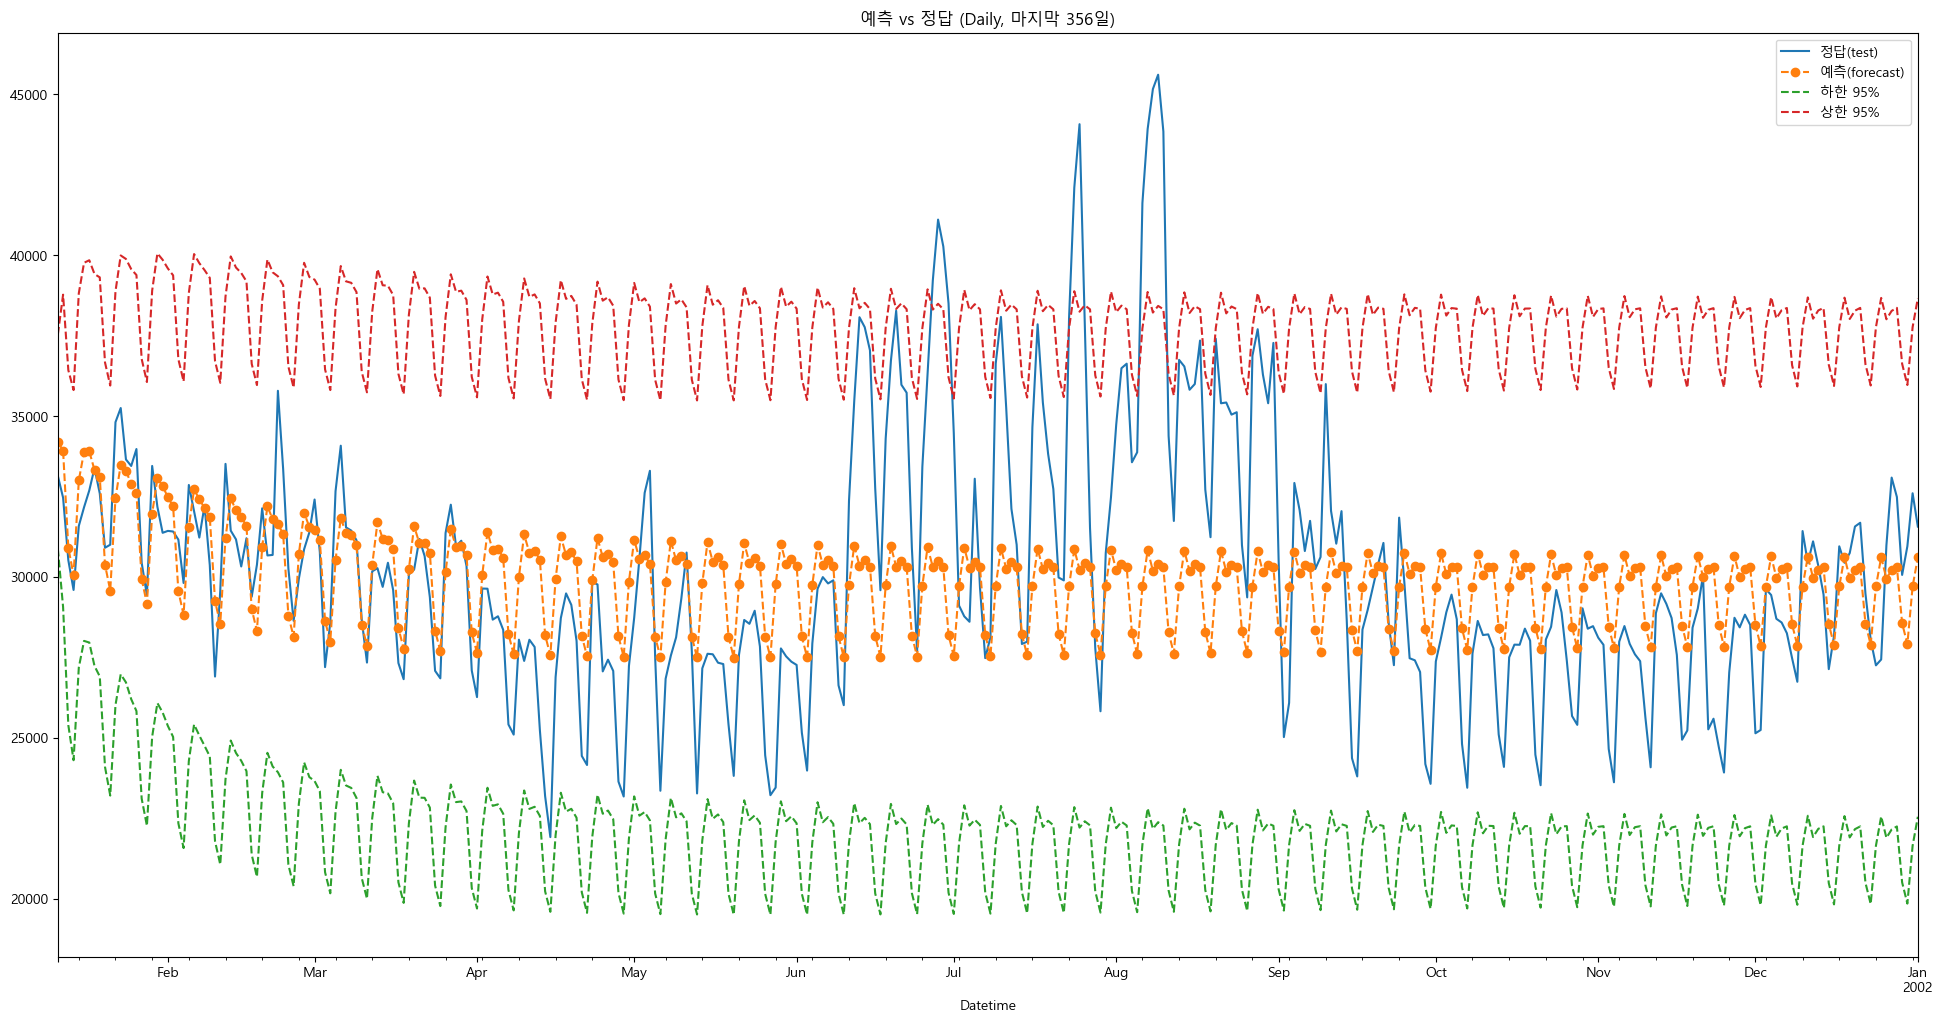

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Monthly 데이터 RMSE = 1985.663
Monthly 데이터 MAPE = 4.50%


c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


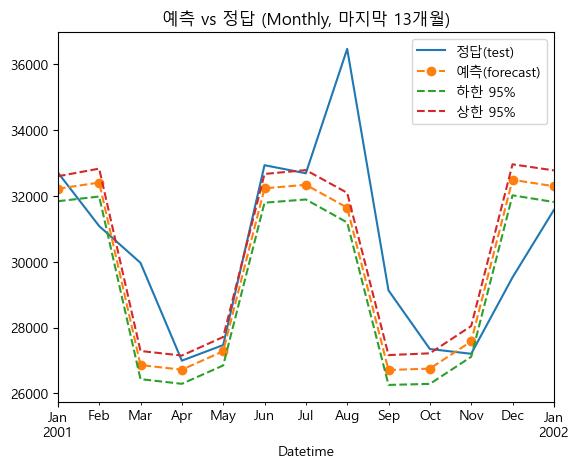

In [12]:
q_daily = 14
d_daily = 0
p_daily = 9

q_monthly = 7
d_monthly = 0
p_monthly = 4

# 일별 ARIMA 예측
model_daily = ARIMA(y_daily_train, order=(p_daily, d_daily, q_daily))
fit_daily = model_daily.fit()
fc_daily = fit_daily.get_forecast(steps=h1)
pred_daily = fc_daily.predicted_mean
ci_daily   = fc_daily.conf_int(alpha=0.05)
lower_daily, upper_daily = ci_daily.iloc[:,0], ci_daily.iloc[:,1]

# 인덱스 맞추기
pred_daily.index = y_daily_test.index
lower_daily.index = y_daily_test.index
upper_daily.index = y_daily_test.index

rmse_daily = float(np.sqrt(np.mean((y_daily_test.values - pred_daily.values)**2)))
mape_daily = float(np.mean(np.abs((y_daily_test.values - pred_daily.values) / y_daily_test.values))) * 100

print(f"Daily 데이터 RMSE = {rmse_daily:.3f}")
print(f"Daily 데이터 MAPE = {mape_daily:.2f}%")

plt.figure(figsize=(24, 12))
plt.title("예측 vs 정답 (Daily, 마지막 356일)")
y_daily_test.plot(label="정답(test)")
pred_daily.plot(label="예측(forecast)", linestyle="--", marker="o")
lower_daily.plot(linestyle="--", label="하한 95%")
upper_daily.plot(linestyle="--", label="상한 95%")
plt.legend()
plt.show()


# 월별 ARIMA 예측
model_monthly = ARIMA(y_monthly_train, order=(p_monthly, d_monthly, q_monthly))
fit_monthly = model_monthly.fit()
fc_monthly = fit_monthly.get_forecast(steps=h2)
pred_monthly = fc_monthly.predicted_mean
ci_monthly   = fc_monthly.conf_int(alpha=0.05)
lower_monthly, upper_monthly = ci_monthly.iloc[:,0], ci_monthly.iloc[:,1]

# 인덱스 맞추기
pred_monthly.index = y_monthly_test.index
lower_monthly.index = y_monthly_test.index
upper_monthly.index = y_monthly_test.index

rmse_monthly = float(np.sqrt(np.mean((y_monthly_test.values - pred_monthly.values)**2)))
mape_monthly = float(np.mean(np.abs((y_monthly_test.values - pred_monthly.values) / y_monthly_test.values))) * 100

print(f"Monthly 데이터 RMSE = {rmse_monthly:.3f}")
print(f"Monthly 데이터 MAPE = {mape_monthly:.2f}%")

plt.figure()
plt.title("예측 vs 정답 (Monthly, 마지막 13개월)")
y_monthly_test.plot(label="정답(test)")
pred_monthly.plot(label="예측(forecast)", linestyle="--", marker="o")
lower_monthly.plot(linestyle="--", label="하한 95%")
upper_monthly.plot(linestyle="--", label="상한 95%")
plt.legend()
plt.show()

# 아래에서 성능 비교를 위해
ARIMA_rmse_daily = rmse_daily
ARIMA_mape_daily = mape_daily

ARIMA_rmse_monthly = rmse_monthly
ARIMA_mape_monthly = mape_monthly

# Prophet 모델 예측

# 3-1. Prophet 모델 기반 적용

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
21:30:42 - cmdstanpy - INFO - Chain [1] start processing
21:30:43 - cmdstanpy - INFO - Chain [1] done processing
21:30:43 - cmdstanpy - INFO - Chain [1] start processing
21:30:43 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


월별 Prophet RMSE = 1828.43, MAPE = 4.32%
일별 Prophet RMSE = 3910.03, MAPE = 11.39%


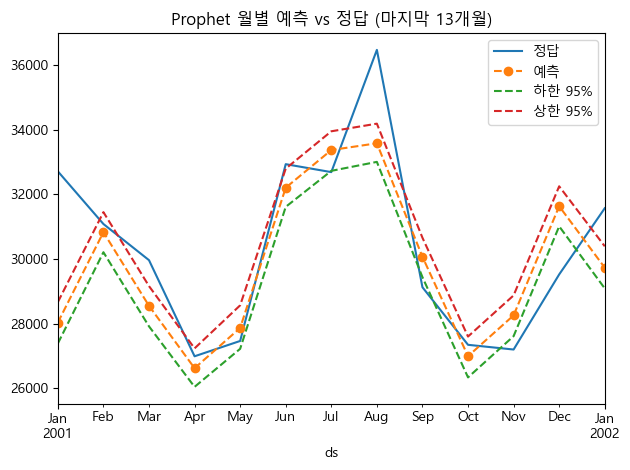

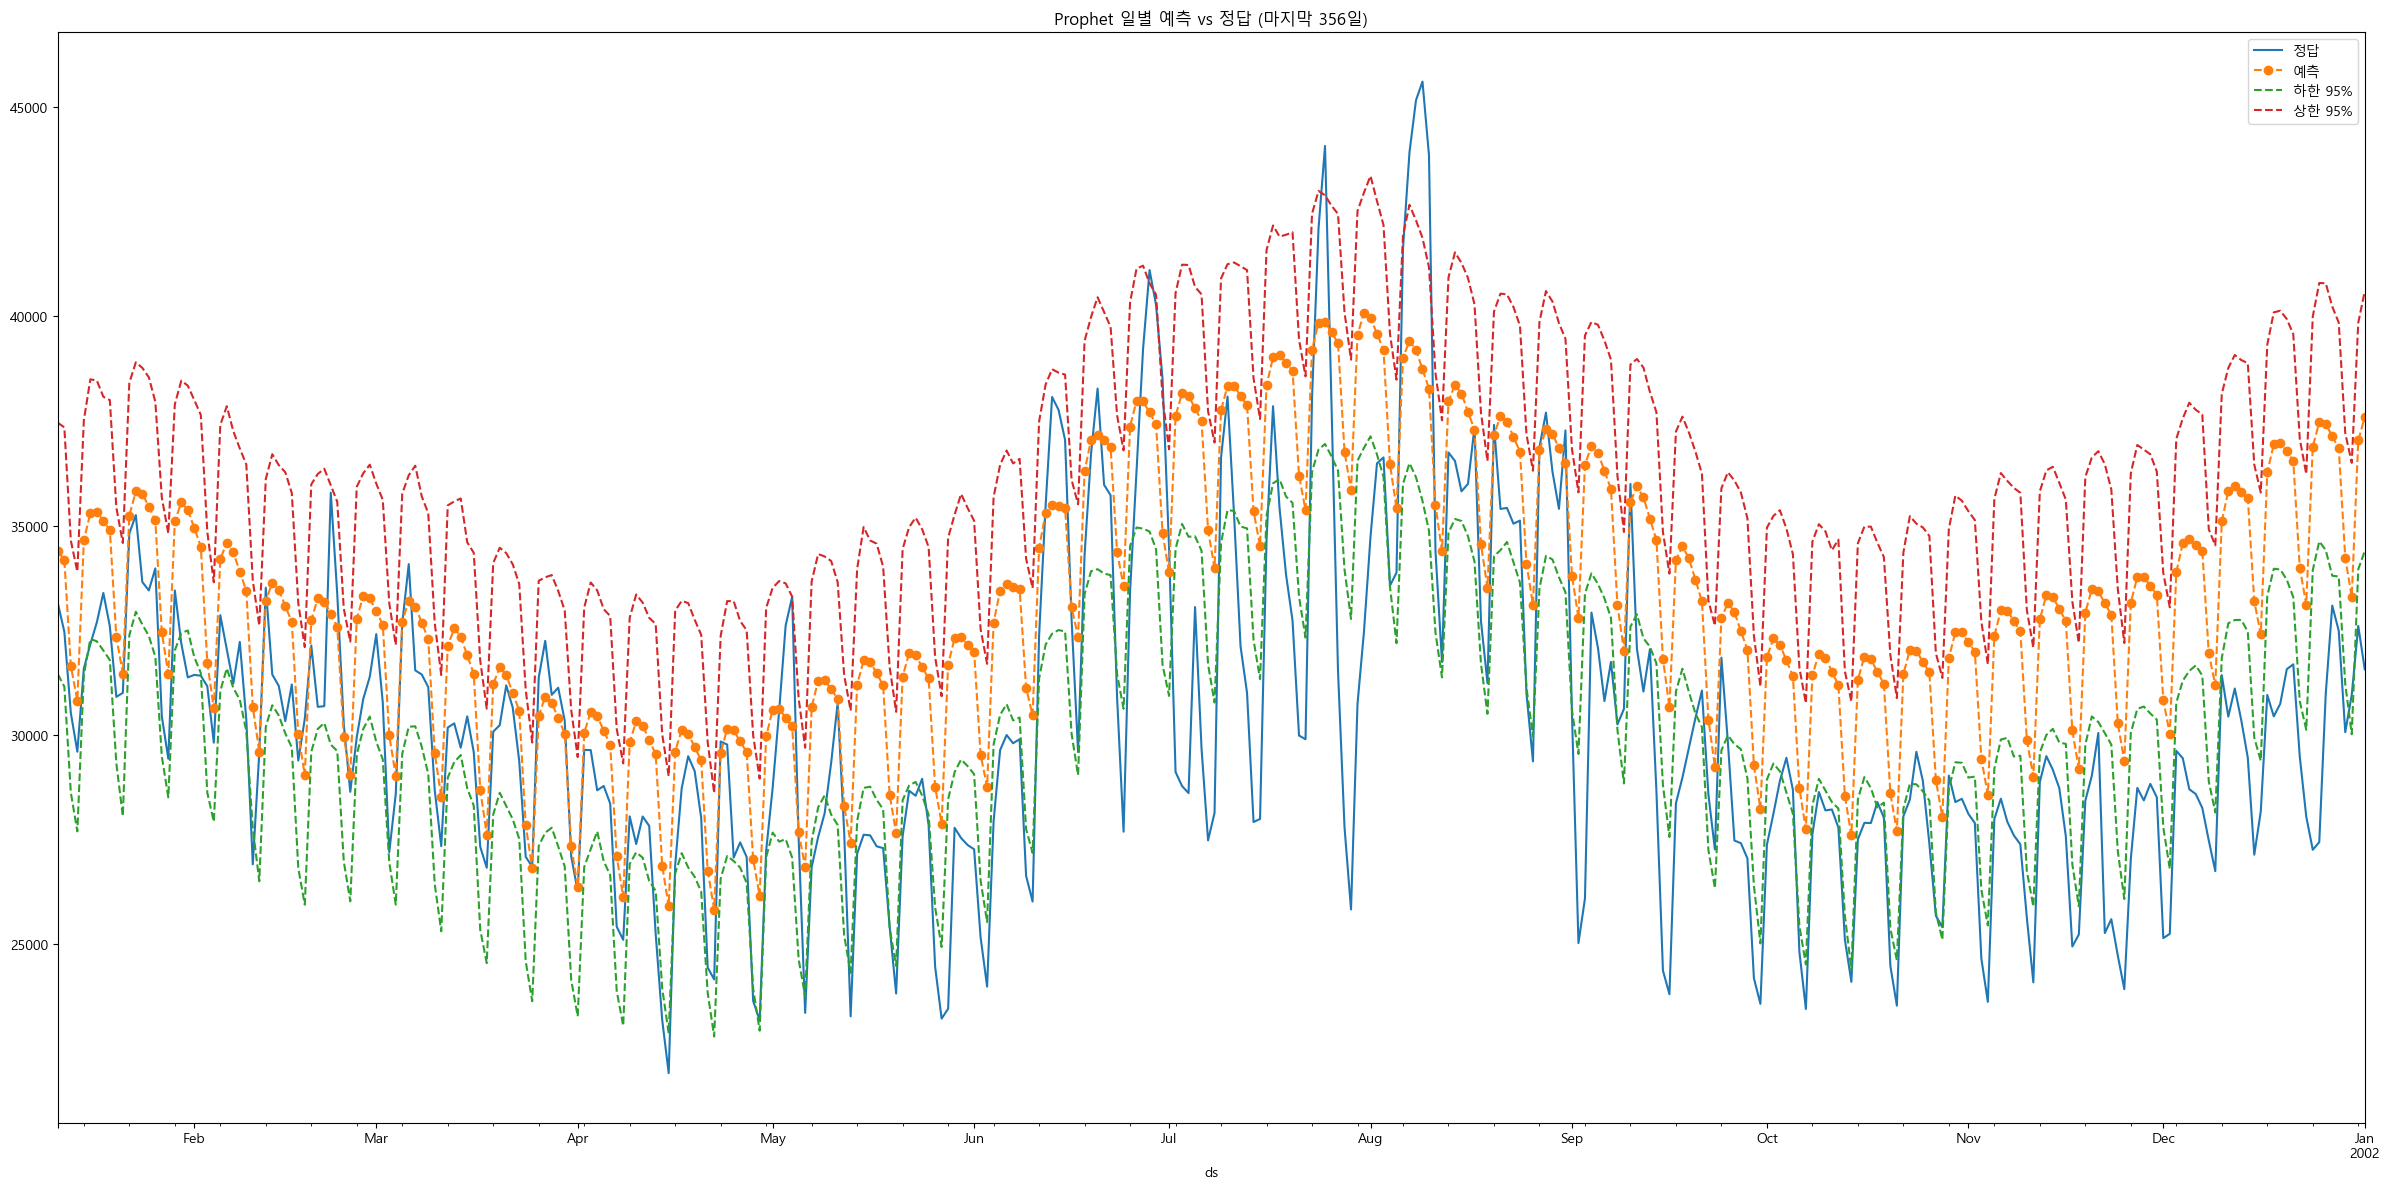

In [13]:
from prophet import Prophet

# prophet는 ds y 형식 사용 / ds 시간 y 예측값
df_monthly_prophet = df_monthly.reset_index()[['Datetime', 'PJM_Load_MW']]
df_monthly_prophet.columns = ['ds', 'y']

df_daily_prophet = df_daily.reset_index()[['Datetime', 'PJM_Load_MW']]
df_daily_prophet.columns = ['ds', 'y']

# seosonality 연, 주 일 계절성을 포함할지말지 설정
model_Prophet_monthly = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_Prophet_daily = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False) 

# fit()
model_Prophet_monthly.fit(df_monthly_prophet.iloc[:-h2])
model_Prophet_daily.fit(df_daily_prophet.iloc[:-h1])

# 월별예측
future_monthly = model_Prophet_monthly.make_future_dataframe(periods=h2, freq='M')
fcst_monthly = model_Prophet_monthly.predict(future_monthly)

# 일별예측
future_daily = model_Prophet_daily.make_future_dataframe(periods=h1, freq='D')
fcst_daily = model_Prophet_daily.predict(future_daily)

# 월별 테스트 데이터 날짜 추출
test_monthly = df_monthly_prophet.iloc[-h2:]
# 일별 테스트 데이터 날짜 추출
test_daily = df_daily_prophet.iloc[-h1:]

# 월별 Prophet
pred_monthly = fcst_monthly.set_index("ds").loc[test_monthly["ds"]]
yhat_monthly = pred_monthly["yhat"]
lower_monthly = pred_monthly["yhat_lower"]
upper_monthly = pred_monthly["yhat_upper"]   

y_true_monthly = test_monthly.set_index("ds")["y"]
rmse_monthly = float(np.sqrt(np.mean((y_true_monthly - yhat_monthly)**2)))
mape_monthly = float(np.mean(np.abs((y_true_monthly - yhat_monthly) / y_true_monthly))) * 100

print(f"월별 Prophet RMSE = {rmse_monthly:.2f}, MAPE = {mape_monthly:.2f}%")


# 일별 Prophet
pred_daily = fcst_daily.set_index("ds").loc[test_daily["ds"]]
yhat_daily = pred_daily["yhat"]
lower_daily = pred_daily["yhat_lower"]
upper_daily = pred_daily["yhat_upper"]

y_true_daily = test_daily.set_index("ds")["y"]
rmse_daily = float(np.sqrt(np.mean((y_true_daily - yhat_daily)**2)))
mape_daily = float(np.mean(np.abs((y_true_daily - yhat_daily) / y_true_daily)))*100

print(f"일별 Prophet RMSE = {rmse_daily:.2f}, MAPE = {mape_daily:.2f}%")


# 월별
plt.figure()
plt.title("Prophet 월별 예측 vs 정답 (마지막 13개월)")
y_true_monthly.plot(label="정답")
yhat_monthly.plot(label="예측", linestyle="--", marker="o")
lower_monthly.plot(linestyle="--", label="하한 95%")
upper_monthly.plot(linestyle="--", label="상한 95%")
plt.legend(); plt.tight_layout(); plt.show()

# 일별
plt.figure(figsize=(24, 12))
plt.title("Prophet 일별 예측 vs 정답 (마지막 356일)")
y_true_daily.plot(label="정답")
yhat_daily.plot(label="예측", linestyle="--", marker="o")
lower_daily.plot(linestyle="--", label="하한 95%")
upper_daily.plot(linestyle="--", label="상한 95%")
plt.legend(); plt.tight_layout(); plt.show()

# Prophet 모델 성능
Prophet_rmse_monthly = rmse_monthly
Prophet_mape_monthly = mape_monthly

Prophet_rmse_daily = rmse_daily
Prophet_mape_daily = mape_daily



# 3-2. ARIMA 모델과 Prophet 모델 성능 비교

In [14]:
# 월별 ARIMA vs Prophet 성능 비교
print(f"ARIMA(월별) RMSE = {ARIMA_rmse_monthly:.2f}, MAPE = {ARIMA_mape_monthly:.2f}%")
print(f"Prophet(월별) RMSE = {Prophet_rmse_monthly:.2f}, MAPE = {Prophet_mape_monthly:.2f}%")  
print("\n")
# 일별 ARIMA vs Prophet 성능 비교
print(f"ARIMA(일별)  RMSE = {ARIMA_rmse_daily:.2f}, MAPE = {ARIMA_mape_daily:.2f}%")
print(f"Prophet(일별) RMSE = {Prophet_rmse_daily:.2f}, MAPE = {Prophet_mape_daily:.2f}%")  

ARIMA(월별) RMSE = 1985.66, MAPE = 4.50%
Prophet(월별) RMSE = 1828.43, MAPE = 4.32%


ARIMA(일별)  RMSE = 3677.69, MAPE = 8.67%
Prophet(일별) RMSE = 3910.03, MAPE = 11.39%


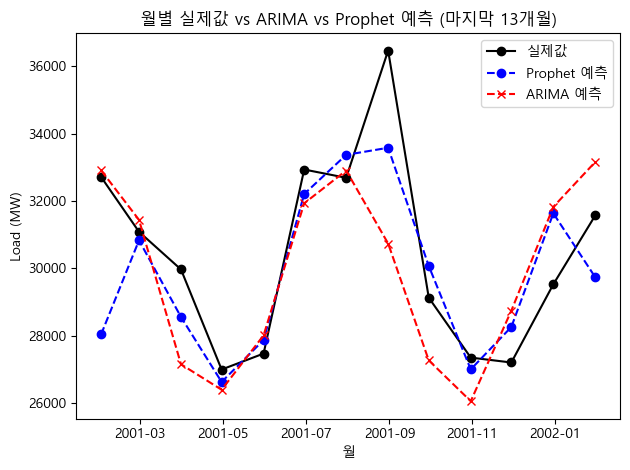

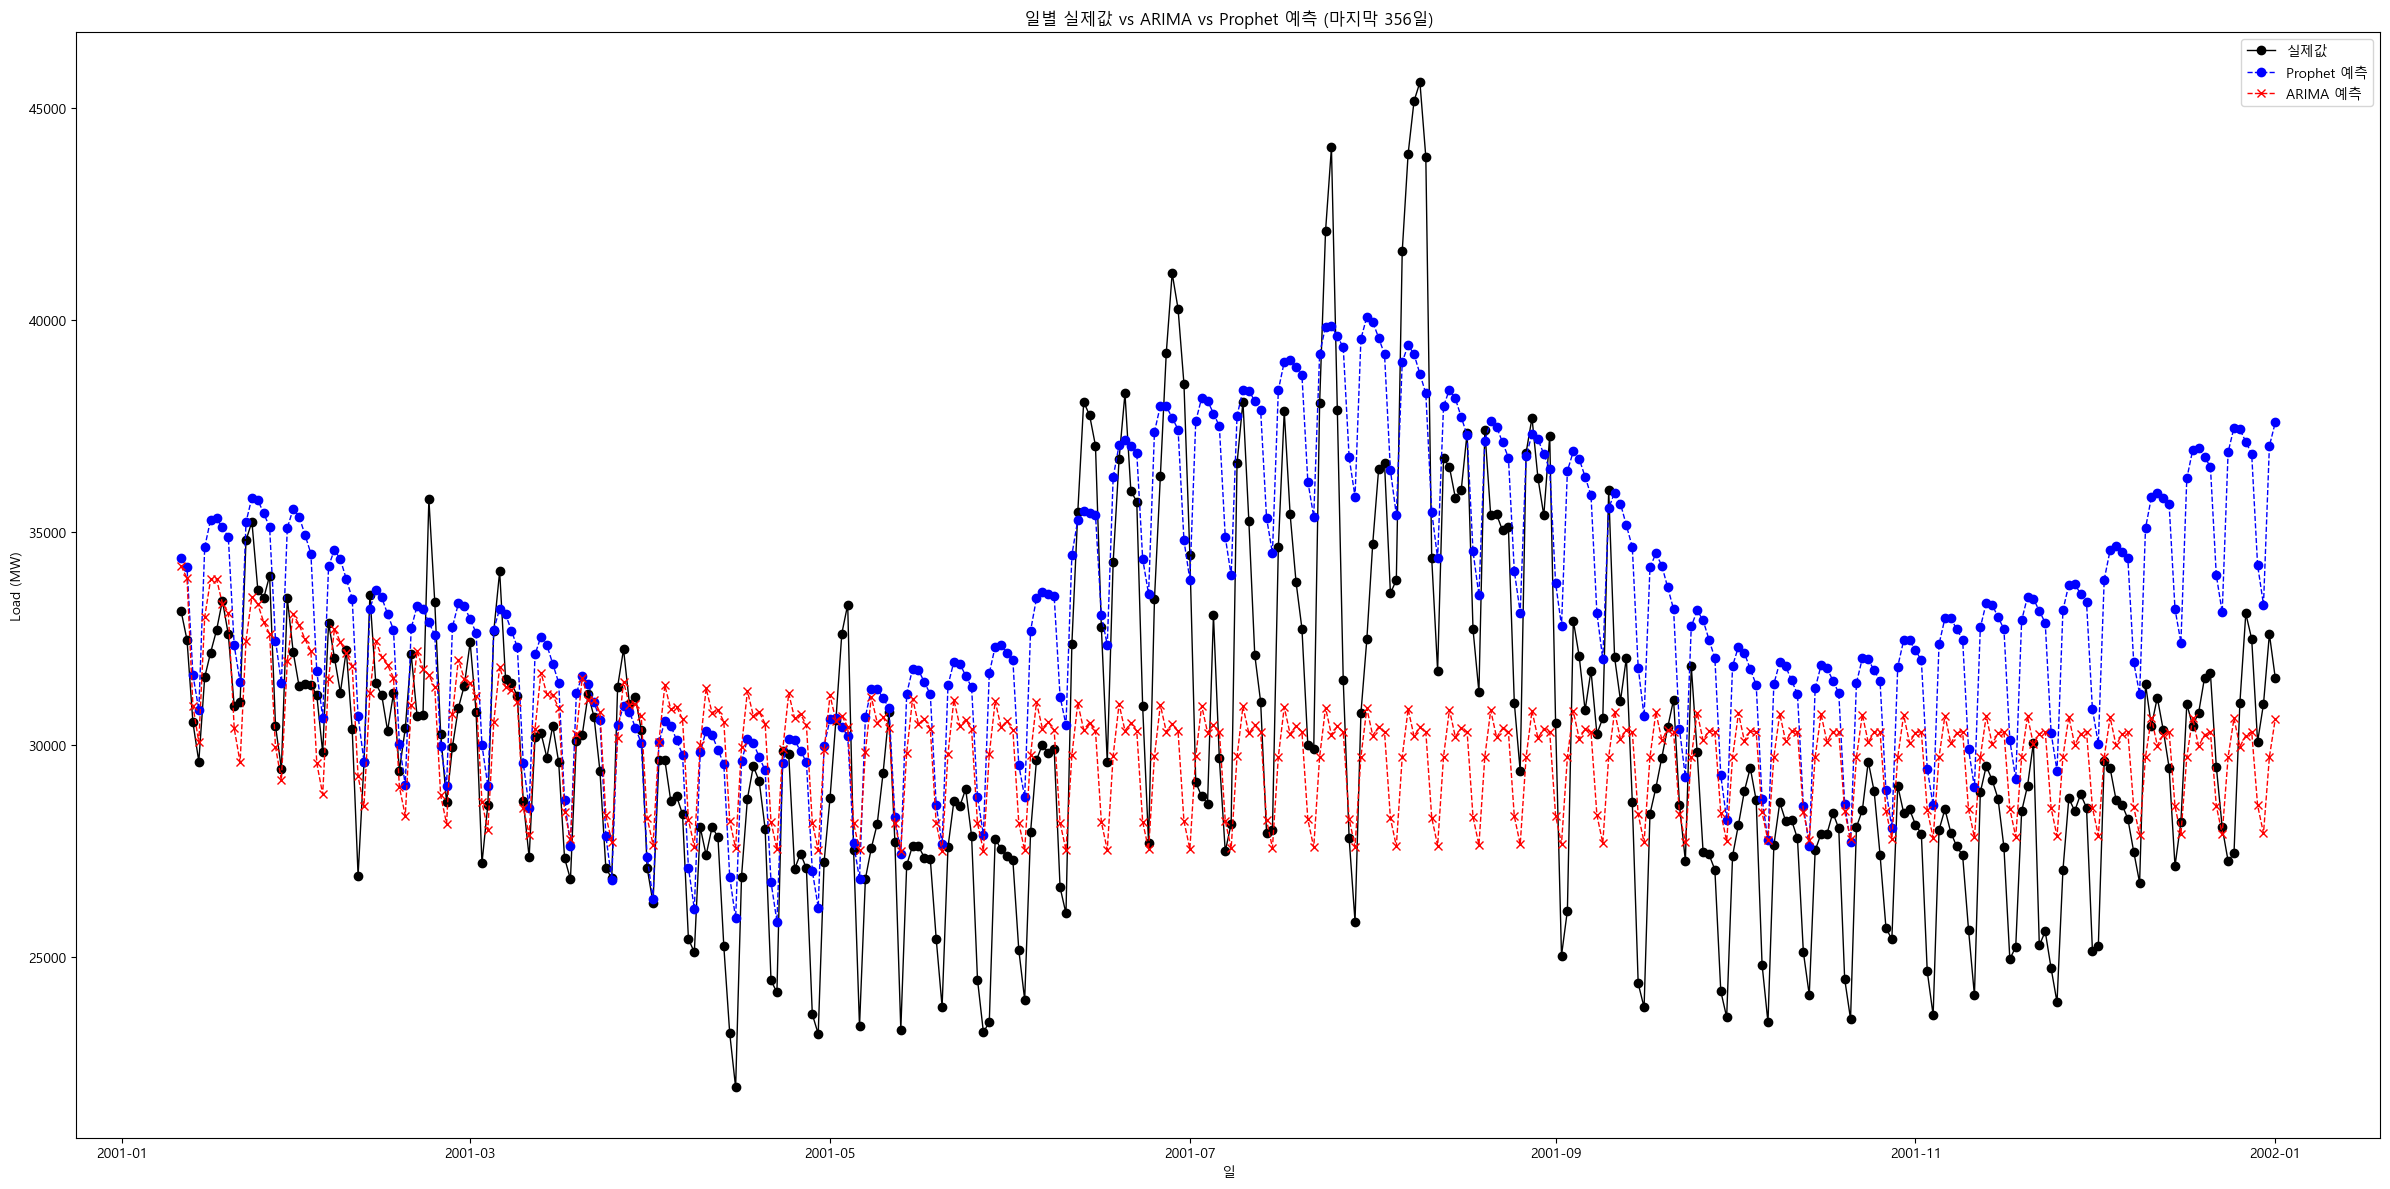

In [15]:

plt.figure()
plt.plot(y_monthly_test.index, y_monthly_test.values, label="실제값", marker='o', color='black')
plt.plot(yhat_monthly.index, yhat_monthly.values, label="Prophet 예측", linestyle="--", marker="o", color='blue')
plt.plot(arima_pred_monthly.index, arima_pred_monthly.values, label="ARIMA 예측", linestyle="--", marker="x", color='red')

plt.title("월별 실제값 vs ARIMA vs Prophet 예측 (마지막 13개월)")
plt.xlabel("월")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(24, 12))
plt.plot(y_daily_test.index, y_daily_test.values, label="실제값", color='black', marker='o', linewidth=1)
plt.plot(yhat_daily.index, yhat_daily.values, label="Prophet 예측", linestyle="--", marker="o", color='blue', linewidth=1)
plt.plot(arima_pred_daily.index, arima_pred_daily.values, label="ARIMA 예측", linestyle="--", marker="x", color='red', linewidth=1)

plt.title("일별 실제값 vs ARIMA vs Prophet 예측 (마지막 356일)")
plt.xlabel("일")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()

